In [52]:
import os

raiz = 'Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


In [53]:
# Realizo el data augmentation para mi conjunto de entrenamiento, validación y prueba
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_generator = ImageDataGenerator(preprocessing_function=preprocess_input,
                                     rotation_range=5,      # Rota la imagen hasta 20 grados
                                     width_shift_range=0.02,  # Mueve la imagen a los lados
                                     height_shift_range=0.02, # Mueve la imagen arriba/abajo
                                     zoom_range=0.2,         # Aplica un 20% de zoom aleatorio
                                     horizontal_flip=True,    # Efecto espejo
)

val_generator = ImageDataGenerator(preprocessing_function=preprocess_input
)

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

In [54]:
# Muestro el antes y después del data augmentation
import matplotlib.pyplot as plt
import numpy as np
# Función para mostrar imágenes
def mostrar_imagenes(generator, dir_normal, dir_glaucoma):
    # Tomo una imagen de cada clase
    img_normal = plt.imread(os.path.join(dir_normal, os.listdir(dir_normal)[0]))
    img_glaucoma = plt.imread(os.path.join(dir_glaucoma, os.listdir(dir_glaucoma)[0]))

    # Aplico el data augmentation a ambas imágenes
    img_normal_aug = generator.random_transform(img_normal)
    img_glaucoma_aug = generator.random_transform(img_glaucoma)

    # Muestro las imágenes originales y aumentadas
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes[0, 0].imshow(img_normal)
    axes[0, 0].set_title('Normal Original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_normal_aug)
    axes[0, 1].set_title('Normal Aumentada')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(img_glaucoma)
    axes[1, 0].set_title('Glaucoma Original')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(img_glaucoma_aug)
    axes[1, 1].set_title('Glaucoma Aumentada')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

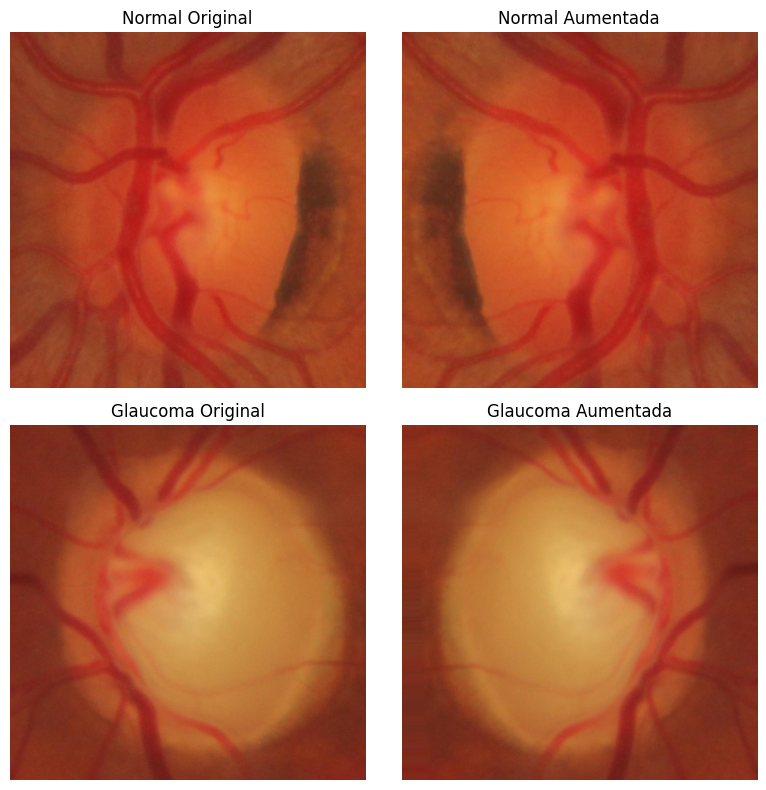

In [55]:
# Muestro la imágen
mostrar_imagenes(train_generator, train_dir_normal, train_dir_glaucoma)

In [56]:
train_generator = train_generator.flow_from_directory(train_dir,
                                    target_size=(224, 224),
                                    class_mode='categorical',
                                    classes=['Normales', 'Glaucomas'],
                                    batch_size=16)

val_generator = val_generator.flow_from_directory(val_dir,
                                  target_size=(224, 224),
                                  class_mode='categorical',
                                  classes=['Normales', 'Glaucomas'],
                                  batch_size=16)

test_generator = test_generator.flow_from_directory(test_dir,
                                   target_size=(224, 224),
                                   class_mode='categorical',
                                   classes=['Normales', 'Glaucomas'],
                                   batch_size=16)

Found 339 images belonging to 2 classes.
Found 48 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


In [57]:
# Obtención del modelo VGG16 preentrenado sin la parte de clasificación (sin las capas densas finales)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layers in base_model.layers:
    layers.trainable = False

base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import Sequential

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1000)           │     1,281,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         2,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,540,986 (13.51 MB)

 Trainable params: 1,283,002 (4.89 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [64]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

name_model = 'models/glaucomaMobileNetV2.h5'

checkpoint = ModelCheckpoint(name_model,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

model.fit(train_generator,
          epochs=200,
          validation_data=val_generator,
          callbacks=[checkpoint])

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.6773 - loss: 0.6578
Epoch 1: val_accuracy improved from None to 0.64583, saving model to models/glaucomaMobileNetV2.h5



Epoch 1: finished saving model to models/glaucomaMobileNetV2.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - accuracy: 0.6519 - loss: 0.6742 - val_accuracy: 0.6458 - val_loss: 0.7442
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.6937 - loss: 0.6737
Epoch 2: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.6873 - loss: 0.6491 - val_accuracy: 0.6250 - val_loss: 0.7143
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6743 - loss: 0.6082
Epoch 3: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.7080 - loss: 0.5783 - val_accuracy: 0.5833 - val_loss: 0.6916
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7137 - loss: 0.5495
Epoch 4: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.7345 - loss: 0.5463 - val_accuracy: 0.5833 - val_loss: 0.6892
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step 


Epoch 12: finished saving model to models/glaucomaMobileNetV2.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.7699 - loss: 0.4639 - val_accuracy: 0.6875 - val_loss: 0.6074
Epoch 13/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7863 - loss: 0.4401
Epoch 13: val_accuracy did not improve from 0.68750
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.8024 - loss: 0.4246 - val_accuracy: 0.6875 - val_loss: 0.6016
Epoch 14/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7611 - loss: 0.5099
Epoch 14: val_accuracy improved from 0.68750 to 0.72917, saving model to models/glaucomaMobileNetV2.h5



Epoch 14: finished saving model to models/glaucomaMobileNetV2.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.7906 - loss: 0.4639 - val_accuracy: 0.7292 - val_loss: 0.5944
Epoch 15/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7825 - loss: 0.4451
Epoch 15: val_accuracy did not improve from 0.72917
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.7817 - loss: 0.4478 - val_accuracy: 0.7292 - val_loss: 0.5851
Epoch 16/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8305 - loss: 0.4386
Epoch 16: val_accuracy did not improve from 0.72917
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.8142 - loss: 0.4359 - val_accuracy: 0.6458 - val_loss: 0.5958
Epoch 17/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7559 - loss: 0.4898
Epoch 17: val_accuracy improved from 0.72917 to 0.75000, saving model to models/glaucomaMobileNetV2.h5



Epoch 17: finished saving model to models/glaucomaMobileNetV2.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.7758 - loss: 0.4591 - val_accuracy: 0.7500 - val_loss: 0.5738
Epoch 18/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8044 - loss: 0.4215
Epoch 18: val_accuracy did not improve from 0.75000
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.7965 - loss: 0.4325 - val_accuracy: 0.6875 - val_loss: 0.5837
Epoch 19/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8386 - loss: 0.3844
Epoch 19: val_accuracy did not improve from 0.75000
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step - accuracy: 0.8171 - loss: 0.4152 - val_accuracy: 0.6875 - val_loss: 0.5821
Epoch 20/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8193 - loss: 0.4151
Epoch 20: val_accuracy did not improve from 0.75000
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.8289 - loss: 0.3976 - val_accuracy: 0.7292 - val_loss: 0.5710
Epoch 21/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 219


Epoch 26: finished saving model to models/glaucomaMobileNetV2.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8142 - loss: 0.3915 - val_accuracy: 0.7708 - val_loss: 0.5474
Epoch 27/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8442 - loss: 0.3681
Epoch 27: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.7965 - loss: 0.4103 - val_accuracy: 0.7500 - val_loss: 0.5456
Epoch 28/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8258 - loss: 0.4051
Epoch 28: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.8201 - loss: 0.3989 - val_accuracy: 0.7292 - val_loss: 0.5662
Epoch 29/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8303 - loss: 0.3476
Epoch 29: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.8230 - loss: 0.3629 - val_accuracy: 0.7500 - val_loss: 0.5564
Epoch 30/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 222

In [65]:
model.load_weights(name_model)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.7755 - loss: 0.4559
test_acc: 0.7755101919174194
test_loss: 0.4558667838573456


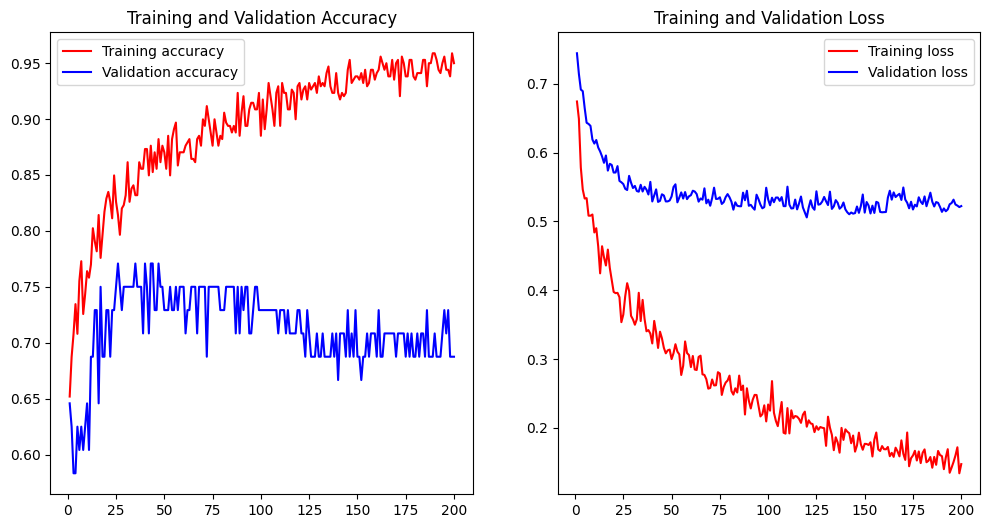

In [66]:
# Pinto las curvas de entrenamiento y validación

# Muestro las gráficas de entrenamiento
import matplotlib.pyplot as plt

# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [69]:
from tensorflow.keras.optimizers import Adam

model.load_weights('models/glaucomaMobileNetV2.h5')

model.trainable = True # Descongelo todas las capas para el deep-tuning

name_deep = 'models/glaucomaMobileNetV2_deep.h5'

checkpointDeep = ModelCheckpoint(name_deep,
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator,
          epochs=200,
          validation_data=val_generator,
          callbacks=[checkpointDeep])

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8254 - loss: 0.3749
Epoch 1: val_accuracy improved from None to 0.70833, saving model to models/glaucomaMobileNetV2_deep.h5



Epoch 1: finished saving model to models/glaucomaMobileNetV2_deep.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - accuracy: 0.8201 - loss: 0.3754 - val_accuracy: 0.7083 - val_loss: 0.5657
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8158 - loss: 0.3793
Epoch 2: val_accuracy improved from 0.70833 to 0.75000, saving model to models/glaucomaMobileNetV2_deep.h5



Epoch 2: finished saving model to models/glaucomaMobileNetV2_deep.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.8260 - loss: 0.3819 - val_accuracy: 0.7500 - val_loss: 0.5521
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8213 - loss: 0.4059
Epoch 3: val_accuracy did not improve from 0.75000
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.8437 - loss: 0.3946 - val_accuracy: 0.7292 - val_loss: 0.5598
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8502 - loss: 0.3219
Epoch 4: val_accuracy improved from 0.75000 to 0.77083, saving model to models/glaucomaMobileNetV2_deep.h5



Epoch 4: finished saving model to models/glaucomaMobileNetV2_deep.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.8466 - loss: 0.3462 - val_accuracy: 0.7708 - val_loss: 0.5450
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8278 - loss: 0.4121
Epoch 5: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8348 - loss: 0.3627 - val_accuracy: 0.7500 - val_loss: 0.5438
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8757 - loss: 0.3549
Epoch 6: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.8791 - loss: 0.3453 - val_accuracy: 0.7500 - val_loss: 0.5511
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8655 - loss: 0.3646
Epoch 7: val_accuracy did not improve from 0.77083
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step - accuracy: 0.8525 - loss: 0.3786 - val_accuracy: 0.7500 - val_loss: 0.5531
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/


Epoch 16: finished saving model to models/glaucomaMobileNetV2_deep.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step - accuracy: 0.8673 - loss: 0.3346 - val_accuracy: 0.7917 - val_loss: 0.5293
Epoch 17/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8621 - loss: 0.3281
Epoch 17: val_accuracy did not improve from 0.79167
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.8643 - loss: 0.3235 - val_accuracy: 0.7708 - val_loss: 0.5362
Epoch 18/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8672 - loss: 0.3343
Epoch 18: val_accuracy did not improve from 0.79167
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.8673 - loss: 0.3175 - val_accuracy: 0.7292 - val_loss: 0.5469
Epoch 19/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8932 - loss: 0.2825
Epoch 19: val_accuracy did not improve from 0.79167
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8643 - loss: 0.3222 - val_accuracy: 0.7917 - val_loss: 0.5281
Epoch 20/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0

In [70]:
model.load_weights(name_deep)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8061 - loss: 0.4259
test_acc: 0.8061224222183228
test_loss: 0.4258735179901123


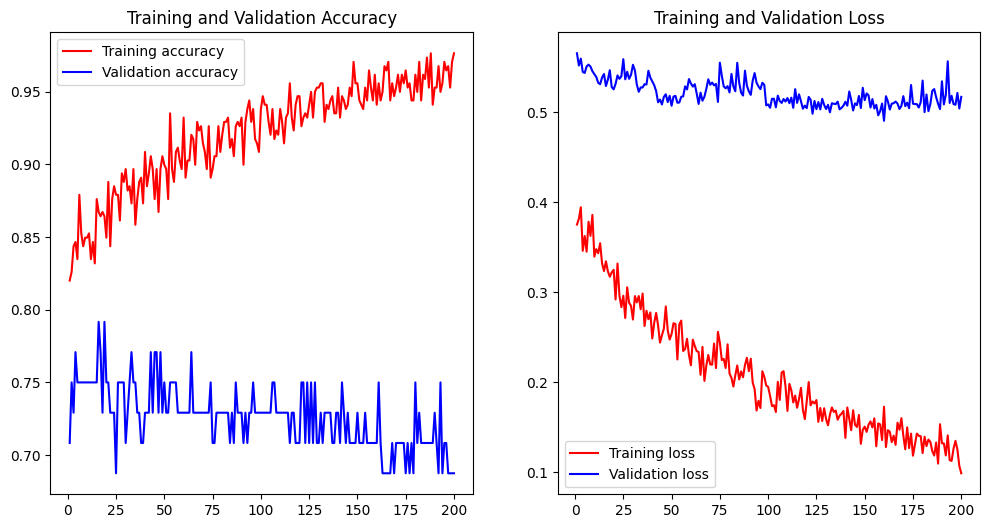

In [71]:
# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()